# Detecção de duplicatas semânticas

Base **demonstrativa sintética**, autorizada para substituir a base oficial ausente. São 40 manifestações fictícias, seis pares rotulados e cinco textos com mais de 500 caracteres. Os pares M003/M017, M008/M022 e M008/M031 mantêm os temas indicados no enunciado. O gabarito não foi usado para treinar os modelos. Os resultados abaixo são de execução real, não valores ilustrativos.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.metrics.pairwise import cosine_similarity
from ouvidoria import carregar_base, codificar, detectar_duplicatas, dividir, projetar, MODELOS
df = carregar_base()
Path('resultados').mkdir(exist_ok=True)
pd.set_option('display.max_colwidth', 160)
display(df.head())


C:\Users\Usuario\Desktop\ricardo\.venv-validacao\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,id,data,categoria_oficial,texto
0,M001,2026-08-01,infraestrutura,A calçada da Rua das Flores está quebrada em frente ao número 20. Pessoas com cadeira de rodas precisam circular pela pista.
1,M002,2026-08-02,meio ambiente,"Há lixo acumulado no terreno da Rua do Sol, ao lado do número 45. O descarte atrai moscas e produz mau cheiro."
2,M003,2026-08-03,infraestrutura,"Há um buraco enorme na Av. Brasil, perto do número 100, sentido centro. A cratera causa acidentes e precisa de reparo."
3,M004,2026-08-04,educação,A Escola Municipal Aurora está sem professor de matemática no oitavo ano há três semanas. Pedimos reposição das aulas.
4,M005,2026-08-05,segurança,Moradores relatam assaltos no ponto de ônibus da Rua das Acácias à noite. Solicitamos patrulhamento no local.


Usamos cosseno estritamente maior que 0,85, sem diagonal e sem repetir pares. O limiar é uma escolha inicial conservadora do enunciado, e não um valor ótimo comprovado. Duplicata significa o mesmo evento e local, não apenas assunto parecido.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3800.85it/s]

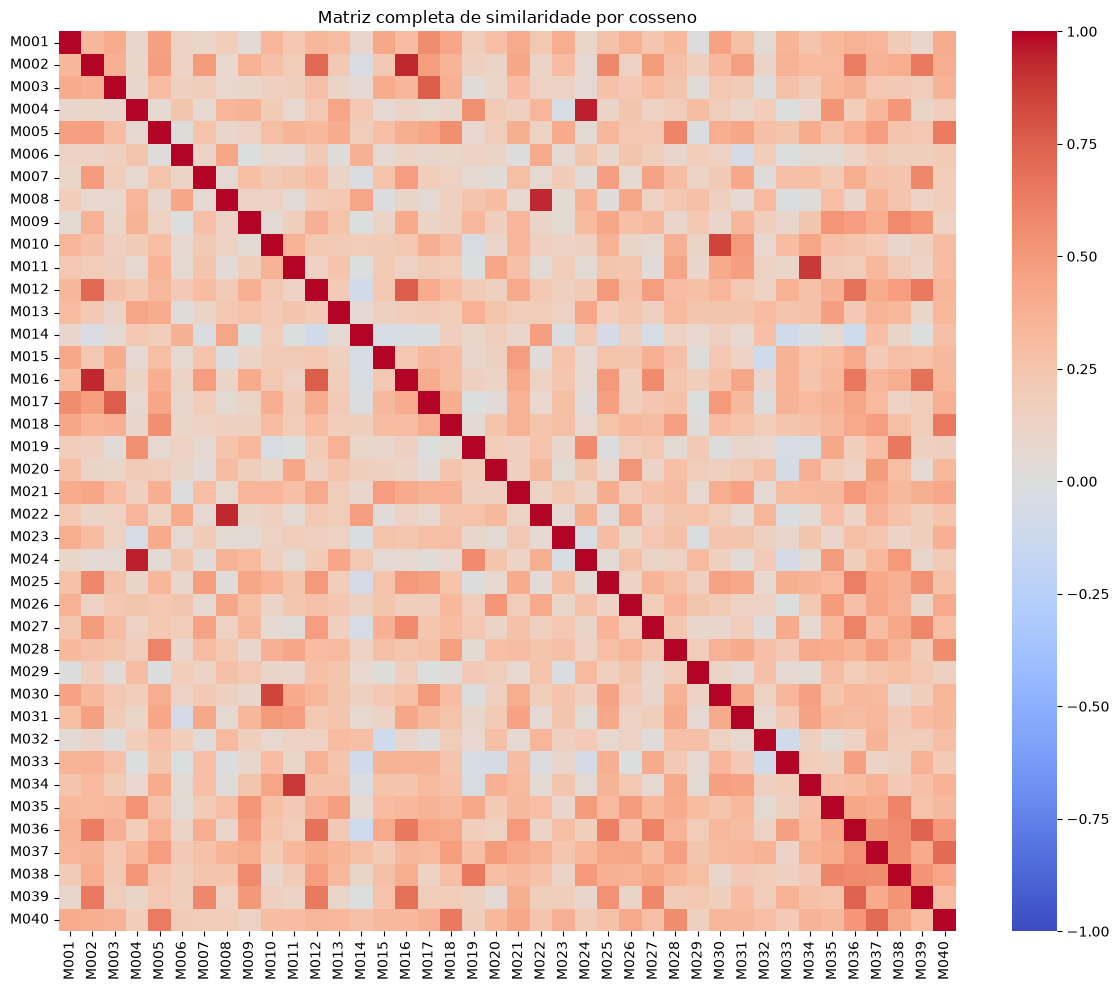

,id_a,id_b,score
0,M002,M016,0.931027
1,M004,M024,0.951258
2,M008,M022,0.933847
3,M011,M034,0.882892


In [2]:
vetores = codificar(df.texto)
matriz = vetores @ vetores.T
plt.figure(figsize=(12,10))
sns.heatmap(matriz,xticklabels=df.id,yticklabels=df.id,vmin=-1,vmax=1,cmap='coolwarm')
plt.title('Matriz completa de similaridade por cosseno')
plt.tight_layout(); plt.savefig('resultados/heatmap.png',dpi=160); plt.show()
pd.DataFrame(matriz,index=df.id,columns=df.id).to_csv('resultados/matriz_similaridade.csv')
pares = detectar_duplicatas(df.texto.tolist(), limiar=.85)
encontrados = pd.DataFrame([{'id_a':df.iloc[i].id,'id_b':df.iloc[j].id,'score':s} for i,j,s in pares],columns=['id_a','id_b','score'])
display(encontrados)
encontrados.to_csv('resultados/duplicatas.csv',index=False)


In [3]:
reais = {tuple(sorted(p)) for p in json.loads(Path('dados/duplicatas_reais.json').read_text())}
def avaliar(limiar):
    previstos = {(df.iloc[i].id,df.iloc[j].id) for i in range(len(df)) for j in range(i+1,len(df)) if matriz[i,j]>limiar}
    tp,fp,fn = len(previstos & reais),len(previstos-reais),len(reais-previstos)
    return {'limiar':limiar,'TP':tp,'FP':fp,'FN':fn,'precisao':tp/(tp+fp) if tp+fp else 0,'recall':tp/(tp+fn) if tp+fn else 0,'f1':2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0}, previstos
metricas = pd.DataFrame([avaliar(t)[0] for t in [.65,.70,.75,.80,.85,.90,.95]])
display(metricas)
metricas.to_csv('resultados/metricas_duplicatas.csv',index=False)
m, previstos = avaliar(.85)
erros = []
for tipo,pares_erro in [('Falso positivo',previstos-reais),('Falso negativo',reais-previstos)]:
    for a,b in sorted(pares_erro):
        i,j = df.index[df.id==a][0],df.index[df.id==b][0]
        erros.append({'tipo':tipo,'id_a':a,'id_b':b,'score':float(matriz[i,j]),'texto_a':df.iloc[i].texto,'texto_b':df.iloc[j].texto})
display(pd.DataFrame(erros))
Path('resultados/erros_duplicatas.json').write_text(json.dumps(erros,ensure_ascii=False,indent=2),encoding='utf-8')
display(Markdown(f'No limiar 0,85: **{m["TP"]} verdadeiros positivos, {m["FP"]} falsos positivos e {m["FN"]} falsos negativos**. Precisão {m["precisao"]:.1%}; recall {m["recall"]:.1%}.'))
for erro in erros:
    explicacao = 'A afinidade temática superou o limiar, mas o gabarito não identifica o mesmo evento. Comparar local e fatos antes de unir.' if erro['tipo']=='Falso positivo' else 'A reformulação do mesmo evento ficou abaixo do limiar. Um limiar menor pode recuperar o par, com possível aumento de falsos positivos.'
    display(Markdown(f"**{erro['tipo']} {erro['id_a']}/{erro['id_b']} ({erro['score']:.3f}):** {explicacao}"))


,limiar,TP,FP,FN,precisao,recall,f1
0,0.65,6,8,0,0.428571,1.000000,0.600000
1,0.70,6,4,0,0.600000,1.000000,0.750000
2,0.75,6,1,0,0.857143,1.000000,0.923077
3,0.80,5,0,1,1.000000,0.833333,0.909091
4,0.85,4,0,2,1.000000,0.666667,0.800000
5,0.90,3,0,3,1.000000,0.500000,0.666667
6,0.95,1,0,5,1.000000,0.166667,0.285714


,tipo,id_a,id_b,score,texto_a,texto_b
0,Falso negativo,M003,M017,0.760968,"Há um buraco enorme na Av. Brasil, perto do número 100, sentido centro. A cratera causa acidentes e precisa de reparo.","O asfalto está todo esburacado na avenida principal, chamada Av. Brasil, junto ao número 100 no sentido centro. O buraco provoca acidentes."
1,Falso negativo,M010,M030,0.844573,"O semáforo do cruzamento da Rua Norte com a Avenida Central está apagado desde ontem, causando confusão no trânsito.",O sinal de trânsito entre a Avenida Central e a Rua Norte não acende desde ontem. Os veículos atravessam sem controle.


No limiar 0,85: **4 verdadeiros positivos, 0 falsos positivos e 2 falsos negativos**. Precisão 100.0%; recall 66.7%.

**Falso negativo M003/M017 (0.761):** A reformulação do mesmo evento ficou abaixo do limiar. Um limiar menor pode recuperar o par, com possível aumento de falsos positivos.

**Falso negativo M010/M030 (0.845):** A reformulação do mesmo evento ficou abaixo do limiar. Um limiar menor pode recuperar o par, com possível aumento de falsos positivos.

**Discussão.** A tabela de limiares é uma análise de sensibilidade sobre a mesma base, não validação independente. Em produção, deve-se calibrar com pares rotulados de outro período, avaliar precisão e recall e reservar revisão humana para casos limítrofes. A maioria dos 780 pares possíveis é negativa, por isso acurácia isolada seria pouco informativa. O gabarito sintético considera seis pares e permite medir erros, mas não substitui a comparação com as duplicatas reais da base oficial. Similaridade temática alta sem coincidência de local ou evento pode gerar falso positivo; abreviações, negação e contexto ausente podem produzir falso negativo.